# 01 — Investigative EDA

Five investigative questions (see `project_CONTEXT.md`):
1. Are the labels trustworthy?
2. Is there temporal drift Day 1 vs Day 2?
3. Are there distinct fraud archetypes?
4. What's the cost distribution of fraud?
5. Are V features independent within Class=1?

Goal: surface at least 2 non-obvious findings.

In [31]:
import sys
from pathlib import Path

# Project root = parent of the notebooks/ folder
PROJECT_ROOT = Path.cwd().parent

# Make project root importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Standard imports
import pandas as pd
import numpy as np

# Path to the raw dataset
RAW_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "creditcard.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw CSV path: {RAW_CSV_PATH}")
print(f"CSV exists: {RAW_CSV_PATH.exists()}")


Project root: c:\Users\ADULT\Downloads\fraud-detector
Raw CSV path: c:\Users\ADULT\Downloads\fraud-detector\data\raw\creditcard.csv
CSV exists: True


In [32]:
from fraud.data_loader import load_raw
# Load the raw dataset
df = load_raw()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# clean default stlye 
sns.set_theme(style="whitegrid")
# Plot the distribution of the 'Class' variable
plt.rcParams["figure.figsize"] = (10,6)


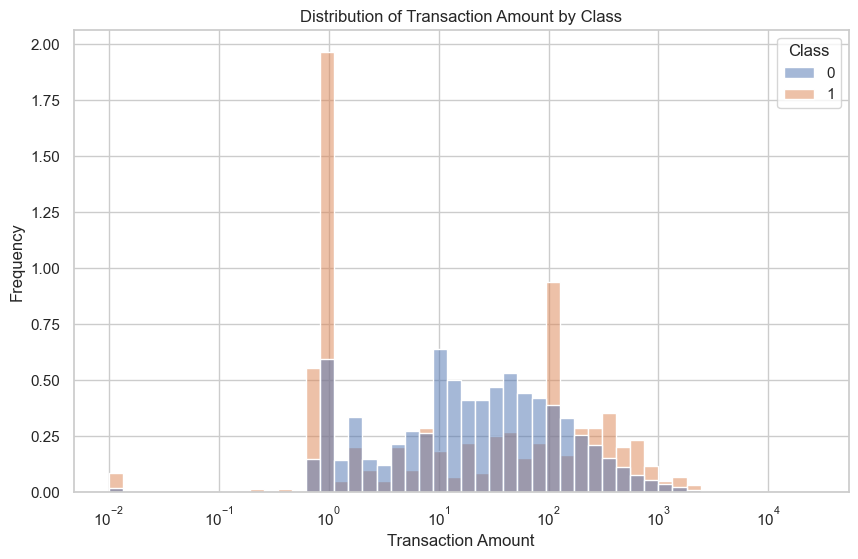

In [34]:
# seaborn histogram of amount , split by ckass 
sns.histplot(data=df, x="Amount", hue="Class", log_scale=True, stat="density", common_norm=False, bins=50)
plt.title("Distribution of Transaction Amount by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

**Observations:**
**1. Fraud usually happens at reasonable amount(100) but first they try to test it with lower amounts(1).**
**2. orange = fraud (class1), blue = legit (class=0), each normalised to its own.**


In [35]:
# median amount for fraud vs legit transactions
median_amount_fraud = df[df["Class"] == 1]["Amount"].median()
median_amount_legit = df[df["Class"] == 0]["Amount"].median()   
print(f"Median amount for fraud transactions: {median_amount_fraud}")
print(f"Median amount for legit transactions: {median_amount_legit}")
# mean amount for fraud vs legit transactions
mean_amount_fraud = df[df["Class"] == 1]["Amount"].mean()
mean_amount_legit = df[df["Class"] == 0]["Amount"].mean()
print(f"Mean amount for fraud transactions: {mean_amount_fraud}")
print(f"Mean amount for legit transactions: {mean_amount_legit}")
# what percentage of fraud transactions are under £2
fraud_under_2 = df[(df["Class"] == 1) & (df["Amount"] < 2)].shape[0]
total_fraud = df[df["Class"] == 1].shape[0]
percentage_fraud_under_2 = (fraud_under_2 / total_fraud) * 100
print(f"Percentage of fraud transactions under £2: {percentage_fraud_under_2:.2f}%")
# what percentage of legit transactions are under £2
legit_under_2 = df[(df["Class"] == 0) & (df["Amount"] < 2)].shape[0]
total_legit = df[df["Class"] == 0].shape[0] 
percentage_legit_under_2 = (legit_under_2 / total_legit) * 100
print(f"Percentage of legit transactions under £2: {percentage_legit_under_2:.2f}%")


Median amount for fraud transactions: 9.25
Median amount for legit transactions: 22.0
Mean amount for fraud transactions: 122.21132113821139
Mean amount for legit transactions: 88.29102242231328
Percentage of fraud transactions under £2: 39.63%
Percentage of legit transactions under £2: 16.46%


**Fraud and legitimate transactions don’t actually resemble each other in amount patterns. Fraud shows a much lower median but a higher mean, revealing a heavily skewed distribution. Nearly 40% of frauds are tiny sub‑£2 charges, far more than in legitimate activity. This suggests two fraud clusters: widespread card‑testing micro‑transactions and a smaller set of large, high‑value attacks.**


In [36]:
# sanity check - about time 
# convert 'Time' to hours
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour"].describe()

count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

In [37]:
# fruad transactions by hour
fraud_rate_by_hour = df.groupby("Hour")["Class"].mean()
fraud_count_by_hour = df[df["Class"] == 1].groupby("Hour").size() 
print("Fraud rate by hour:")
print(fraud_rate_by_hour*100)  # Convert to percentage
print("Fraud count by hour:")
print(fraud_count_by_hour)  


Fraud rate by hour:
Hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64
Fraud count by hour:
Hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
dtype: int64


In [38]:
# check if the amount of fraud transction is higher or lower also give statasitics 
fraud_amount_by_hour = df[df["Class"] == 1].groupby("Hour")["Amount"].describe()
print("Fraud amount statistics by hour:")
print(fraud_amount_by_hour)



Fraud amount statistics by hour:
      count        mean         std   min      25%      50%       75%      max
Hour                                                                          
0.0     6.0  303.345000  351.961260  0.00   3.1875  230.240  509.5675   829.41
1.0    10.0  127.932000  191.817996  1.00   9.7425   45.725  194.6975   600.73
2.0    57.0   79.262807  254.233308  0.01   1.0000    1.000   44.9000  1809.68
3.0    17.0   13.759412   43.370506  0.00   1.0000    1.000    1.0000   179.66
4.0    23.0   67.313043  172.048729  0.00   0.9600    2.280   16.7150   766.36
5.0    11.0  128.788182  365.908372  1.00   1.0000    1.000    1.0000  1218.89
6.0     9.0  111.924444  206.669487  0.00   1.0000    3.120   99.9900   635.10
7.0    23.0  119.903478  135.513963  3.76  99.9900   99.990   99.9900   730.86
8.0     9.0   47.887778   47.705985  0.68   0.6800   30.300  104.8100   105.89
9.0    16.0   78.463125  177.016583  0.00   3.8000   16.710   73.3750   717.15
10.0    8.0  293.70

**Hypothesis — I originally assumed that nighttime fraud would involve larger, high‑value transactions.
Finding — What I actually found is that late‑night fraud is mostly made up of tiny £1 card‑testing attempts.
Evidence — Around 2am the fraud rate rises to roughly 1.7%, and the median amount drops to £1, though this needs the usual small‑sample caution.
Interpretation — This pattern suggests that automated card‑testing systems are running during hours when monitoring is minimal.**

C:\Users\ADULT\AppData\Local\Temp\ipykernel_15328\1728560212.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ADULT\AppData\Local\Temp\ipykernel_15328\1728560212.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


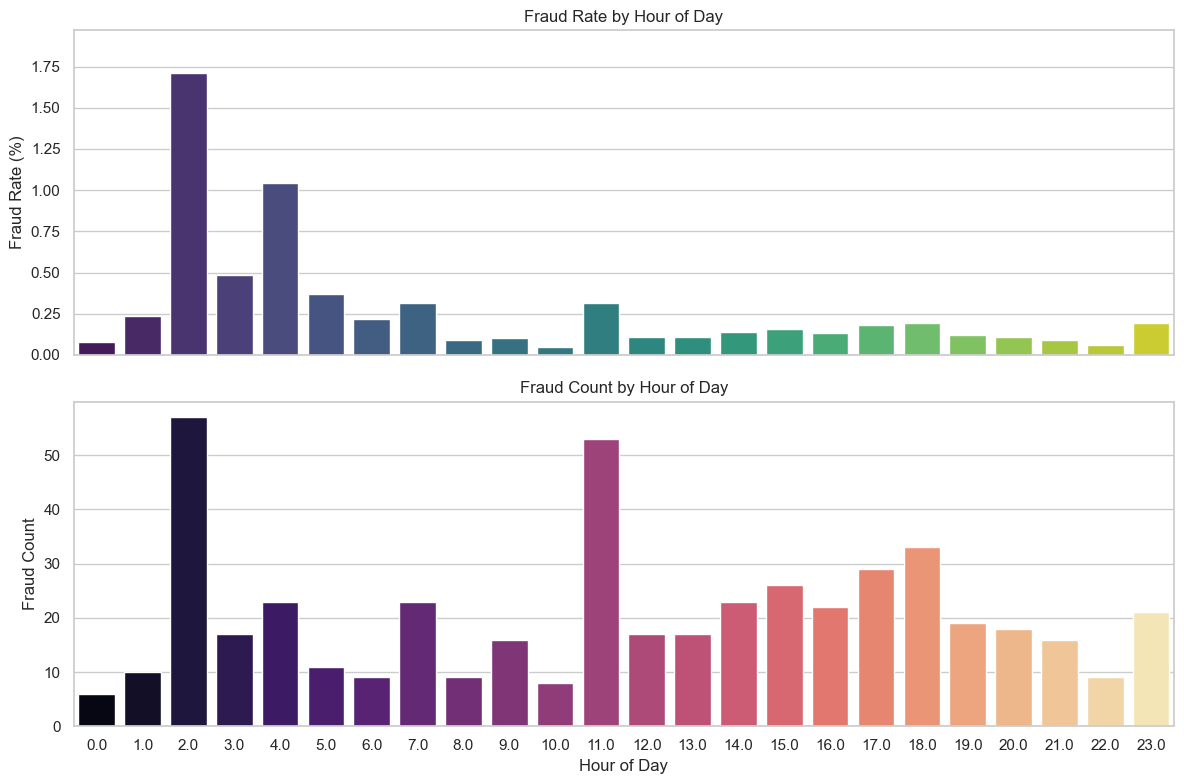

In [39]:
# Chart of fraud rate by hour + fraud count by hour
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# -----------------------------
# Top panel: FRAUD RATE by hour
# -----------------------------
sns.barplot(
    x=fraud_rate_by_hour.index,
    y=fraud_rate_by_hour.values * 100,
    ax=axes[0],
    palette="viridis"
)

axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_ylim(0, (fraud_rate_by_hour.values * 100).max() * 1.15)

# -----------------------------
# Bottom panel: FRAUD COUNT by hour
# -----------------------------
sns.barplot(
    x=fraud_count_by_hour.index,
    y=fraud_count_by_hour.values,
    ax=axes[1],
    palette="magma"
)

axes[1].set_ylabel("Fraud Count")
axes[1].set_xlabel("Hour of Day")
axes[1].set_title("Fraud Count by Hour of Day")

plt.tight_layout()
plt.show()


In [40]:
# Mean of each feature, split by class
class_means = df.groupby("Class").mean()

# Gap between fraud (row 1) and legit (row 0) for each feature
separation = (class_means.loc[1] - class_means.loc[0]).sort_values()

print(separation)

Time     -14091.395347
V3           -7.045452
V14          -6.983787
V17          -6.677371
V12          -6.270225
V10          -5.686707
V7           -5.578368
V1           -4.780206
V16          -4.147110
V5           -3.156678
V9           -2.585589
Hour         -2.404282
V18          -2.250195
V6           -1.400155
V13          -0.109523
V24          -0.105312
V15          -0.093090
V23          -0.040378
V22           0.014073
V25           0.041521
V26           0.051738
V28           0.075798
V27           0.170870
V20           0.372964
V8            0.571623
V19           0.681837
V21           0.714823
V2            3.630049
V11           3.806749
V4            4.549889
Amount       33.920299
dtype: float64


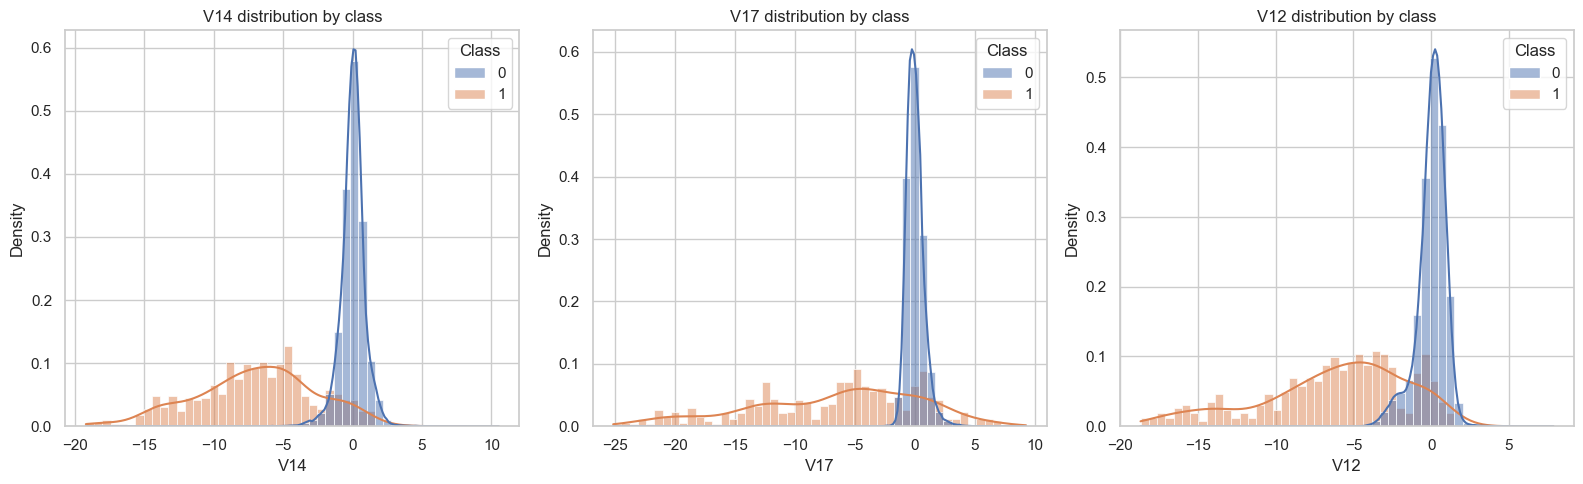

In [41]:
features_to_plot = ["V14", "V17", "V12"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feature in enumerate(features_to_plot):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        stat="density",
        common_norm=False,
        ax=axes[i],          # <- this is the new bit: tells seaborn which panel
        # think: do you want kde overlaid? bins?
        kde=True,
        bins=50 
    )
    axes[i].set_title(f"{feature} distribution by class")

plt.tight_layout()
plt.show()

**Here’s a clean, first‑person paraphrase you can drop straight into the Markdown cell:

**What I’m checking:** whether these V‑features actually separate fraud from legitimate transactions in a meaningful way.

**Finding:** the legitimate points bunch tightly around zero, while the fraud cases pull left into the negative range and fan out much more widely on V14, V17, and V12.

**Evidence:** the large mean gaps (around −7, −6.7, and −6.3) now show up clearly in the shape of the distributions.

**Interpretation + forward link:** these three should rank near the top of the SHAP list on Thursday, and the overlapping middle band is exactly where I expect most of the model’s misclassifications to land.**

In [47]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
from fraud.data_loader import load_raw

df = load_raw()

In [46]:
suspects = df[(df["Class"] == 0) & (df["iso_pred"] == -1)]
suspects[["Amount", "V14", "V17", "V12"]].describe()

,Amount,V14,V17,V12
count,363.000000,363.000000,363.000000,363.000000
mean,2314.675785,-0.439090,-1.155860,-0.482395
std,3076.561720,4.409683,4.192956,3.897349
min,0.000000,-18.392091,-17.098444,-15.144988
25%,99.745000,-2.482042,-1.491605,-1.222241
50%,1042.800000,0.160607,-0.403241,0.006435
75%,3812.745000,2.000776,0.844586,1.335774
max,25691.160000,10.526766,5.527167,7.848392
